# 05 — Vintage / Cohort Survival Analysis

Builds on `CLAUDE.md` and notebooks `01_`-`04c_`: reuses the target/censoring
vocabulary established in notebook `01_`, and reuses/adapts notebook `03_`'s
numeric + categorical feature set and cleaning logic for the Cox model in
section 8, now with `grade` added back in — fair game here, since Phase 2
analyzes already-issued, already-graded loans rather than Phase 1's
not-yet-underwritten applicant.

**Why the population is different from Phase 1:** Phase 1 modeled resolved
loans only (`Fully Paid` / `Charged Off`) because a static classifier needs a
realized label. Phase 2 is exactly the opposite case — `Current` and `Late`
loans are precisely the right-censored observations survival analysis exists
to handle. This notebook re-pulls the **full population** from the raw CSV
rather than reusing Phase 1's `test_df.parquet` or its resolved-only frame.

**Three design decisions below were proposed and approved before any curve
was built** (sections 4-6) — event definition, the time-to-event field, and
term handling are judgment calls with real consequences for the resulting
curves' shape, not defaults. Each section states the decision, the
alternative that was rejected, and why — consistent with this project's
convention of documenting reasoning, not just conclusions.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter

sys.path.append(str(Path('..').resolve()))
from src.preprocessing import GarbageValueCleaner

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 100)

GOOD_COLOR = '#4C72B0'
BAD_COLOR = '#C44E52'
THIRD_COLOR = '#55A868'
RANDOM_STATE = 42

## 2. Load the full population

Unlike Phase 1, this is **not** restricted to resolved loans or to
`issue_year >= 2013` — `Current`/`Late`/`In Grace Period` loans are exactly
the right-censored observations this analysis needs, and the KM curves
(sections 7-8) benefit from the full 2007-2018 origination history. The
`issue_year >= 2013` restriction only comes back in section 8, scoped to the
Cox model, because that's where the bureau-feature schema-growth issue
(notebook `01_`) actually matters.

One `read_csv` call loads everything both the KM section and the Cox section
need — same "single read, no merge" reasoning as notebook `03_`. Low-
cardinality string columns load as `category` to control memory, same as
every prior notebook. Notebook `01_` already proved this scales: all 151
raw columns / 2.26M rows fit in 4.3GB that way with no chunking. This pull
uses far fewer columns, so no chunked reading is needed here either.

`last_credit_pull_d` is loaded alongside `last_pymnt_d` specifically to
support the time-to-event field comparison in section 5 — it isn't used
anywhere else in this notebook.

In [2]:
DATA_PATH = '../data/accepted_2007_to_2018Q4.csv'

usecols = [
    'id', 'issue_d', 'loan_status', 'term', 'grade', 'home_ownership', 'purpose',
    'verification_status', 'loan_amnt', 'dti', 'annual_inc', 'fico_range_low',
    'open_acc', 'total_acc', 'revol_util', 'emp_length', 'earliest_cr_line',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec', 'acc_now_delinq',
    'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
    'last_pymnt_d', 'last_credit_pull_d',
]
category_cols = [
    'term', 'grade', 'home_ownership', 'purpose', 'verification_status',
    'loan_status', 'emp_length',
]
dtype_map = {c: 'category' for c in category_cols}

df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype_map, low_memory=False)
print(f'Raw load: {df.shape}, {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

# Same trailer-row fix as every prior notebook: a few footer rows carry a
# summary string in `id` (not a null) -- left in, they'd upcast issue_year
# to float via NaT.
n0 = len(df)
df = df[pd.to_numeric(df['id'], errors='coerce').notnull()].copy()
print(f'Trailer-row drop: {n0:,} -> {len(df):,} rows')

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y', errors='coerce')
df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_d'].dt.year
df['issue_quarter'] = df['issue_d'].dt.to_period('Q')

print(f"issue_d range: {df['issue_d'].min().date()} to {df['issue_d'].max().date()}")

Raw load: (2260701, 26), 0.91 GB


Trailer-row drop: 2,260,701 -> 2,260,668 rows


issue_d range: 2007-06-01 to 2018-12-01


## 3. Enumerate `loan_status` and define event / censoring

Per the project brief: don't assume a clean Current/Late/Charged Off/Fully
Paid split. Here's every distinct value actually present in the full
population, mapped explicitly to event vs. censored.

In [3]:
df['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

**Explicit mapping** (folding `Default` into `Charged Off` and the
credit-policy variants into their underlying status, same as notebook `01_`
— `Default` is only 40 rows here too, not worth separate handling):

| `loan_status` | mapping |
|---|---|
| `Charged Off` | event |
| `Default` | event (folded into Charged Off) |
| `Does not meet the credit policy. Status:Charged Off` | event |
| `Fully Paid` | censored — early payoff, per the event-definition decision below |
| `Does not meet the credit policy. Status:Fully Paid` | censored |
| `Current` | censored — genuinely still at risk |
| `In Grace Period` | censored — still at risk |
| `Late (16-30 days)` | censored — still at risk |
| `Late (31-120 days)` | censored — still at risk |

No `Issued` status is present in this file (that value exists in some other
LendingClub extracts, not this one) — confirmed by the enumeration above
rather than assumed.

In [4]:
event_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
]
df['event'] = df['loan_status'].isin(event_statuses).astype(int)

# Sanity check: every loan_status value should appear in exactly one bucket.
df.groupby('loan_status', observed=True)['event'].agg(['mean', 'count'])

,mean,count
loan_status,,
Charged Off,1.00,268559
Current,0.00,878317
Default,1.00,40
Does not meet the credit policy. Status:Charged Off,1.00,761
Does not meet the credit policy. Status:Fully Paid,0.00,1988
Fully Paid,0.00,1076751
In Grace Period,0.00,8436
Late (16-30 days),0.00,4349
Late (31-120 days),0.00,21467


## 4. Decision — event definition: standard KM censoring, not competing risks

**Decision (approved):** `Charged Off` is the only event; `Fully Paid` is
treated as non-informative censoring, same as `Current`/`Late`. A single
Kaplan-Meier curve per cohort, not separate cumulative-incidence functions.

**Why not competing risks:** early payoff is common in this data and isn't
truly random with respect to risk (borrowers who prepay are plausibly
lower-risk to begin with) — a textbook argument for treating it as a
competing terminal event rather than neutral censoring. Standard KM will
run slightly optimistic as a result: it keeps early-payers "at risk" in the
denominator as if they might still default, which they no longer can.

The reason to accept that bias here: `lifelines`/KM is this project's stated
baseline tool and Cox PH is an explicit stretch goal (section 8) — a full
Fine-Gray competing-risks model is real added scope beyond either. This is
a **documented limitation**, not an oversight: the survival curves and
vintage-quality read in sections 7-8 should be read as a mild
over-estimate of "safe," concentrated in cohorts/terms with heavy early
prepayment.

## 5. Decision — time-to-event field: per-loan `last_pymnt_d - issue_d`

**Decision (approved):** duration = months between `issue_d` and
`last_pymnt_d`, computed per loan, used for every loan regardless of
status. Not a single fixed "as-of" snapshot date.

**Why not a fixed cutoff:** the brief's working assumption was "late 2018"
(this file is `accepted_2007_to_2018Q4.csv`). That's wrong — `last_pymnt_d`,
`last_credit_pull_d`, and `next_pymnt_d` all extend into **2019**, and
`last_credit_pull_d` clusters heavily at **2019-03**, which is when this
extract was actually refreshed. Using a single global cutoff also requires
picking one date for every still-open loan; the comparison below shows why
that's worse than a per-loan field.

In [5]:
non_terminal = ['Current', 'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)']
censored_mask = df['loan_status'].isin(non_terminal)


def month_diff(later, earlier):
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)


dur_via_lcp = month_diff(df.loc[censored_mask, 'last_credit_pull_d'], df.loc[censored_mask, 'issue_d'])
dur_via_lpd = month_diff(df.loc[censored_mask, 'last_pymnt_d'], df.loc[censored_mask, 'issue_d'])

comparison = pd.DataFrame({
    'field': ['last_credit_pull_d', 'last_pymnt_d'],
    'null_count': [dur_via_lcp.isnull().sum(), dur_via_lpd.isnull().sum()],
    'negative_duration_count': [(dur_via_lcp < 0).sum(), (dur_via_lpd < 0).sum()],
    'n_censored_loans': [censored_mask.sum(), censored_mask.sum()],
})
comparison

,field,null_count,negative_duration_count,n_censored_loans
0,last_credit_pull_d,15,433,912569
1,last_pymnt_d,102,0,912569


`last_credit_pull_d` produces 433 negative durations (the bureau pull date
predates loan issuance for a small set of records — a data artifact, not a
real observation) and would still require assuming one global snapshot date
for every open loan, which overstates survival time for the ~2% of open
loans whose `last_credit_pull_d` is stale (back to 2018-02, not 2019-03).
`last_pymnt_d` is populated for 99.99%+ of censored loans, never negative,
and gives each loan its own last-known-activity date. That's the field used
below.

In [6]:
df['duration_months'] = month_diff(df['last_pymnt_d'], df['issue_d'])

n_before = len(df)
bad_duration = df['duration_months'].isnull() | (df['duration_months'] <= 0)
print(f'Dropping null/zero/negative duration: {bad_duration.sum():,} / {n_before:,} ({bad_duration.mean():.2%})')
print('(mostly loans reported resolved/refreshed in the same calendar month they were issued -- '
      'too little follow-up time to contribute a valid duration)')

df = df[~bad_duration].copy()
df['is_censored'] = 1 - df['event']
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(int)

print(f'\\nFinal population: {len(df):,} loans')
print(df['event'].value_counts(normalize=True).rename('share'))

Dropping null/zero/negative duration: 11,392 / 2,260,668 (0.50%)
(mostly loans reported resolved/refreshed in the same calendar month they were issued -- too little follow-up time to contribute a valid duration)


\nFinal population: 2,249,276 loans
event
0   0.88
1   0.12
Name: share, dtype: float64


## 6. Decision — term comparability: separate curves per term, never pooled

**Decision (approved, carried forward from notebook `01_`):** 36-month and
60-month loans get fully separate Kaplan-Meier curves. Notebook `01_`
already established why: 60-month cohorts are systematically less seasoned
at any given calendar snapshot than 36-month cohorts from the same
origination quarter, so pooling would confound term-mix with vintage —
a recent 60-month cohort would misleadingly look "safer" than it really is,
purely because it hasn't had time to season.

In [7]:
df.groupby('term_months', observed=True).agg(n=('id', 'size'), event_rate=('event', 'mean'))

,n,event_rate
term_months,,
36,1601630,0.10
60,647646,0.16


## 7. Kaplan-Meier survival curves by origination cohort and term

One `KaplanMeierFitter` fit per `(issue_year, term_months)` group. Cohorts
are colored on a light-to-dark scale by origination year within each term
panel -- the standard "vintage fan chart" layout, so the reader can see
both curve shape (hazard over the life of a loan) and the vintage trend
(whether later cohorts sit above or below earlier ones) in one view.

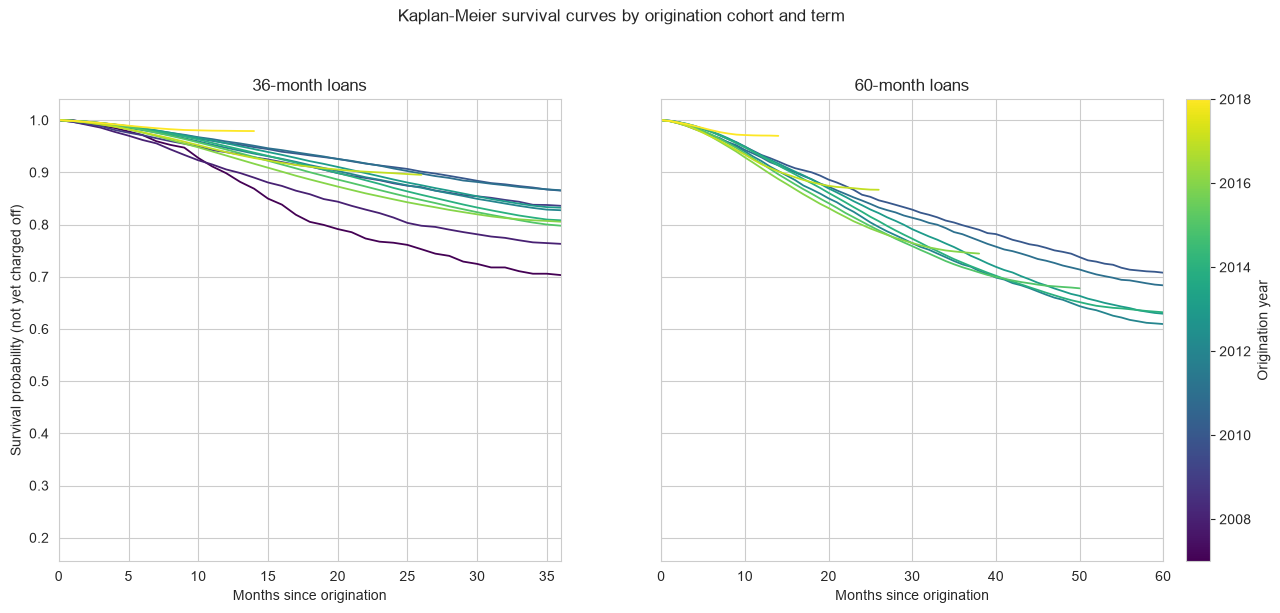

In [8]:
years = sorted(df['issue_year'].unique())
cmap = plt.get_cmap('viridis')
year_colors = {yr: cmap(i / max(len(years) - 1, 1)) for i, yr in enumerate(years)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, term_m in zip(axes, [36, 60]):
    for yr in years:
        sub = df[(df['term_months'] == term_m) & (df['issue_year'] == yr)]
        if len(sub) < 30:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub['duration_months'], event_observed=sub['event'], label=str(yr))
        kmf.survival_function_.plot(ax=ax, color=year_colors[yr], legend=False, linewidth=1.3)
    ax.set_xlim(0, term_m)
    ax.set_title(f'{term_m}-month loans')
    ax.set_xlabel('Months since origination')

axes[0].set_ylabel('Survival probability (not yet charged off)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(years), vmax=max(years)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Origination year')

fig.suptitle('Kaplan-Meier survival curves by origination cohort and term', y=1.03)
plt.savefig('../models/km_fan_chart.png', dpi=100, bbox_inches='tight')
plt.show()

**Reading the shape:** both panels show the expected credit-risk pattern —
a roughly convex decline, steepest in the first 12-18 months (early
defaults dominate) and flattening as the loan seasons. 60-month curves sit
visibly below 36-month curves at any shared duration -- a longer-term loan
carries more cumulative exposure, consistent with the raw default-rate gap
notebook `02_` found (36mo 16.0% vs. 60mo 32.5%) but now decomposed into an
actual time-to-event shape rather than a single endpoint number. Color
alone previews the vintage trend, formalized properly in section 8: darker
(later) curves fall below lighter (earlier) curves through most of the
2011-2016 stretch — later vintages defaulting faster, not just more.

## 8. Maturity-adjusted read: is credit quality getting worse across vintages?

The fan chart's color trend is suggestive but not rigorous -- eyeballing
curve position doesn't separate a real vintage-quality trend from a cohort
simply not having enough follow-up time yet. This section makes that
explicit with a **maturity mask**: for a given horizon *h* months, a cohort
is only fully observable at *h* if even its *last-originated* loan could
have accumulated *h* months of follow-up by the time this extract was
refreshed. Cohorts that fail that test are flagged, not silently plotted
alongside mature ones -- same spirit as notebook `02_`'s >50%-censored
shading, but a sharper, deterministic version of the same idea.

Computed at **quarterly** cohort granularity (the project's stated cohort
unit), at three horizons (12/24/36 months, each only evaluated where
`horizon <= term`).

In [9]:
snapshot_date = df['last_pymnt_d'].max()
print(f'Data snapshot (max observed last_pymnt_d): {snapshot_date.date()}')

quarters = sorted(df['issue_quarter'].unique())
horizons = [12, 24, 36]

rows = []
for term_m in [36, 60]:
    for q in quarters:
        sub = df[(df['term_months'] == term_m) & (df['issue_quarter'] == q)]
        if len(sub) < 30:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub['duration_months'], event_observed=sub['event'])

        # Worst-case (latest-possible) origination date within the quarter,
        # to test whether the *whole* cohort could have reached the horizon.
        cohort_end = q.end_time
        months_available = (snapshot_date.year - cohort_end.year) * 12 + (snapshot_date.month - cohort_end.month)

        for h in horizons:
            if h > term_m:
                continue
            try:
                surv = kmf.survival_function_at_times(h).iloc[0]
            except Exception:
                surv = np.nan
            rows.append({
                'issue_quarter': q, 'term_months': term_m, 'horizon': h,
                'survival': surv, 'n': len(sub), 'is_mature': months_available >= h,
            })

cohort_survival = pd.DataFrame(rows)
cohort_survival['issue_quarter_str'] = cohort_survival['issue_quarter'].astype(str)
cohort_survival.head()

Data snapshot (max observed last_pymnt_d): 2019-03-01


,issue_quarter,term_months,horizon,survival,n,is_mature,issue_quarter_str
0,2007Q3,36,12,0.93,190,True,2007Q3
1,2007Q3,36,24,0.81,190,True,2007Q3
2,2007Q3,36,36,0.76,190,True,2007Q3
3,2007Q4,36,12,0.88,389,True,2007Q4
4,2007Q4,36,24,0.73,389,True,2007Q4


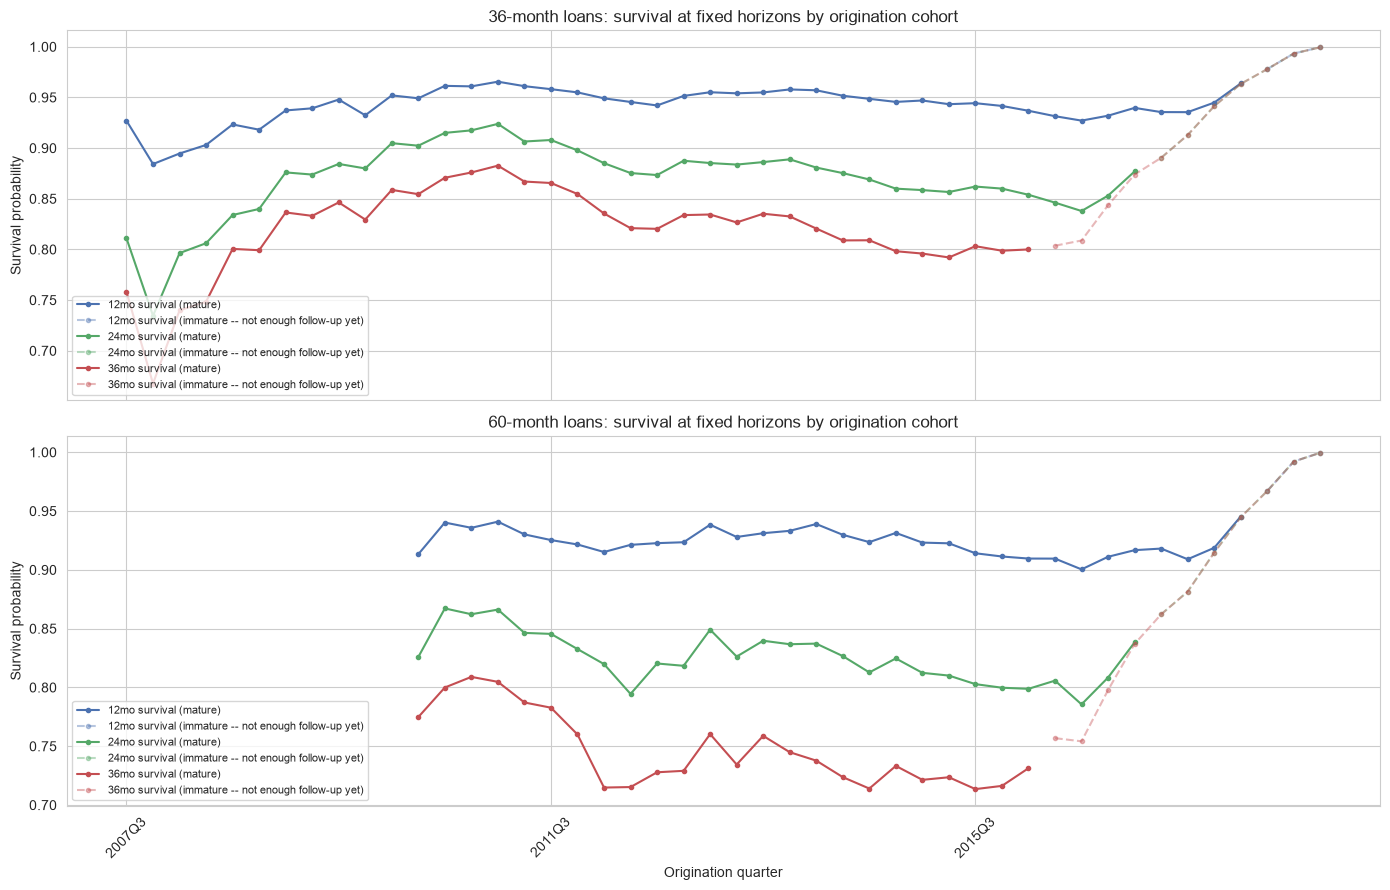

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
horizon_colors = {12: GOOD_COLOR, 24: THIRD_COLOR, 36: BAD_COLOR}

for ax, term_m in zip(axes, [36, 60]):
    plot_df = cohort_survival[cohort_survival['term_months'] == term_m]
    for h in horizons:
        if h > term_m:
            continue
        h_df = plot_df[plot_df['horizon'] == h].sort_values('issue_quarter')
        mature = h_df[h_df['is_mature']]
        immature = h_df[~h_df['is_mature']]
        ax.plot(mature['issue_quarter_str'], mature['survival'], marker='o', markersize=3,
                color=horizon_colors[h], label=f'{h}mo survival (mature)')
        ax.plot(immature['issue_quarter_str'], immature['survival'], marker='o', markersize=3,
                linestyle='--', color=horizon_colors[h], alpha=0.4,
                label=f'{h}mo survival (immature -- not enough follow-up yet)')
    ax.set_title(f'{term_m}-month loans: survival at fixed horizons by origination cohort')
    ax.set_ylabel('Survival probability')
    ax.legend(fontsize=8, loc='lower left')
    ax.set_xticks(ax.get_xticks()[::4])
    ax.tick_params(axis='x', rotation=45)

axes[1].set_xlabel('Origination quarter')
plt.tight_layout()
plt.savefig('../models/vintage_quality_trend.png', dpi=100, bbox_inches='tight')
plt.show()

**Reading the trend, mature cohorts only (solid lines):** there's a real
decline in credit quality from the 2011 vintages into the mid-2010s, but
it's noisier and less monotonic than a single headline number would
suggest -- worth stating precisely rather than rounding off to "steady."
36-month loans at the 12-month horizon go 0.960 (2011) -> 0.947 (2012) ->
0.955 (2013, a partial recovery) -> 0.932 (2016), a real net decline but
with a bump along the way. The decline shows up more cleanly at longer
horizons, where there's more cumulative time for the trend to dominate
quarter-to-quarter noise: at the 36-month horizon, 36mo loans go 0.867
(2011) -> 0.797 (2015) with only a small 2013 wobble, and 60mo loans show
a similar-direction decline (0.784 in 2011 -> 0.719 in 2015). This
corroborates notebook `02_`'s raw resolved-loan default rate (14% in
2009-10 rising to 23% by 2016-17), but now properly conditioned on
survival time instead of a censoring-biased mean -- and shows the trend
isn't as clean as that single-number summary implied.

**The artifact the mask catches:** every dashed segment from 2017 onward is
flagged immature -- these cohorts simply haven't had 12/24/36 months of
possible follow-up by the 2019-03 snapshot, so their apparently high
survival is a right-censoring artifact, not a real improvement. Notebook
`02_`'s raw (non-survival) default-rate-by-year finding flagged 2018 as an
anomaly for the same underlying reason without this formal mask -- this
section makes that judgment call explicit and mechanical rather than a
qualitative aside.

**Term-mix control:** because every curve above is already term-separated
(section 6), the 2011-2016 decline in each panel is a same-term comparison
-- it isn't an artifact of the 60-month share of originations growing over
time (notebook `01_` showed 60mo share did grow through 2015). No macro
overlay (unemployment rate) is applied here -- flagged in the brief as
optional/stretch, and no macro dataset is present in this repo yet, so
whether the decline tracks a broader credit cycle vs. LendingClub-specific
underwriting drift is an open question this notebook doesn't resolve.

## 9. Cox Proportional Hazards model (stretch goal)

**Population:** restricted to `issue_year >= 2013`, same restriction as
Phase 1 and for the same reason (notebook `01_`) -- the bureau-feature
cluster used below is schema-absent before then, not sparse-but-real.

**Feature set:** reuses notebook `03_`'s 16 numeric + garbage-value cleaning
logic (imported from `src/preprocessing.GarbageValueCleaner`, not
reimplemented) and its 4 categorical features, **plus `grade`** -- excluded
in Phase 1 as post-underwriting leakage for a not-yet-underwritten
applicant, but a legitimate covariate here since Phase 2 analyzes
already-graded, already-issued loans (CLAUDE.md's Phase 1 model artifact
notes make this same distinction explicit).

`CoxPHFitter` needs a flat numeric/dummy-encoded frame, not the
`ColumnTransformer`/`Pipeline` machinery notebook `03_` built for the
classifiers -- so categoricals are one-hot encoded directly via
`pd.get_dummies` here rather than reusing that pipeline object wholesale.
`home_ownership`'s `ANY`/`NONE` categories and `purpose`'s
`renewable_energy`/`educational` are folded into their nearest larger
bucket (`OTHER` / `other`) first -- left as-is, these near-empty dummy
columns produced a non-convergent fit (a near-complete-separation failure
in `lifelines`' Newton-Raphson solver), a data reality rather than a
tuning choice.

Fit on the **full** 2013+ population (not a subsample) -- runtime testing
showed a full fit (~2.15M rows, 41 covariates) takes ~17 seconds, so unlike
notebook `03_`'s logistic regression grid search, there's no need to trade
population size for tractability here.

In [11]:
cox_pool = df[df['issue_year'] >= 2013].copy()

emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}
cox_pool['emp_length_numeric'] = cox_pool['emp_length'].map(emp_length_map).astype(float)
cox_pool['earliest_cr_line'] = pd.to_datetime(cox_pool['earliest_cr_line'], format='%b-%Y')
cox_pool['credit_history_years'] = (cox_pool['issue_d'] - cox_pool['earliest_cr_line']).dt.days / 365.25

numeric_features = [
    'loan_amnt', 'dti', 'annual_inc', 'fico_range_low', 'open_acc',
    'total_acc', 'revol_util', 'emp_length_numeric', 'credit_history_years',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec',
    'acc_now_delinq', 'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
]
categorical_features = ['term', 'home_ownership', 'purpose', 'verification_status', 'grade']

# Reuse notebook 03's garbage-value cleaning transformer directly rather than
# re-writing the dti==999 / revol_util>100 / annual_inc<=0 logic inline.
cox_pool[numeric_features] = GarbageValueCleaner().fit_transform(cox_pool[numeric_features])

# Rare-category collapse -- see markdown above for why (convergence failure otherwise).
cox_pool['home_ownership'] = cox_pool['home_ownership'].astype(object).replace(
    {'ANY': 'OTHER', 'NONE': 'OTHER'})
cox_pool['purpose'] = cox_pool['purpose'].astype(object).replace(
    {'renewable_energy': 'other', 'educational': 'other'})

cox_input = cox_pool[numeric_features + categorical_features + ['duration_months', 'event']].copy()
for c in numeric_features:
    cox_input[c] = cox_input[c].fillna(cox_input[c].median())
cox_input = pd.get_dummies(cox_input, columns=categorical_features, drop_first=True)

print(f'Cox input: {cox_input.shape[0]:,} loans, {cox_input.shape[1] - 2} covariates')

Cox input: 2,153,518 loans, 39 covariates


In [12]:
cph = CoxPHFitter(penalizer=0.1)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cph.fit(cox_input, duration_col='duration_months', event_col='event')

print(f'Concordance index: {cph.concordance_index_:.4f}')
cox_summary = cph.summary[['coef', 'exp(coef)', 'se(coef)', 'p']].sort_values('exp(coef)', ascending=False)
cox_summary

Concordance index: 0.6785


,coef,exp(coef),se(coef),p
covariate,,,,
grade_G,0.91,2.49,0.02,0.00
grade_F,0.76,2.14,0.01,0.00
grade_E,0.55,1.73,0.01,0.00
grade_D,0.34,1.41,0.00,0.00
purpose_small_business,0.17,1.18,0.01,0.00
verification_status_Verified,0.14,1.15,0.00,0.00
grade_C,0.12,1.12,0.00,0.00
home_ownership_RENT,0.11,1.12,0.00,0.00
inq_last_6mths,0.10,1.10,0.00,0.00


**Why `penalizer=0.1`:** a light ridge penalty on the partial likelihood.
Without it, the handful of still-rare dummy levels (e.g. `home_ownership_OTHER`
at <0.1% of the population even after collapsing) push the Newton-Raphson
solver toward a non-invertible Hessian -- the same instability the
rare-category collapse above addresses structurally; the penalizer is a
second, complementary safeguard, not a substitute for it.

**Proportional-hazards assumption:** not formally tested here.
`lifelines`' `check_assumptions` (scaled Schoenfeld residuals) did not
complete within several minutes even on a 100K-row subsample of this
population -- computationally impractical at this data's scale within this
notebook's scope. Documented as a limitation: the hazard ratios below
should be read as an average effect over the loan lifetime, not verified as
constant over time.

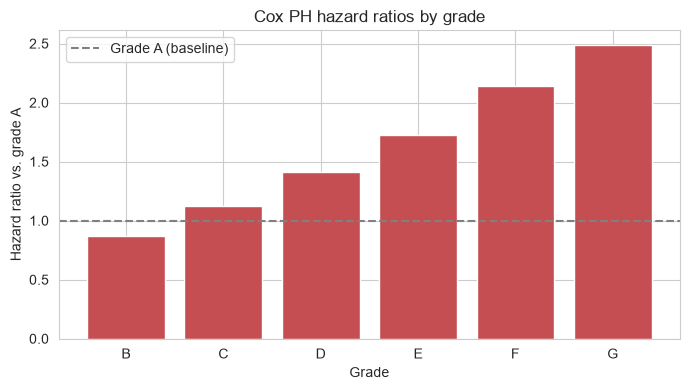

Monotonically increasing hazard B -> G: True


In [13]:
grade_hr = cox_summary.loc[cox_summary.index.str.startswith('grade_'), 'exp(coef)']
grade_hr = grade_hr.reindex(sorted(grade_hr.index))  # grade_C, grade_D, ... grade_G (A is baseline)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(grade_hr.index.str.replace('grade_', ''), grade_hr.values, color=BAD_COLOR)
ax.axhline(1.0, linestyle='--', color='grey', label='Grade A (baseline)')
ax.set_ylabel('Hazard ratio vs. grade A')
ax.set_xlabel('Grade')
ax.set_title('Cox PH hazard ratios by grade')
ax.legend()
plt.tight_layout()
plt.show()

print('Monotonically increasing hazard B -> G:', grade_hr.is_monotonic_increasing)

**Interpretation:** grade's hazard ratios increase monotonically from B
through G relative to A (the omitted baseline category), consistent with
notebook `02_`'s finding that LendingClub's own grade is a clean,
monotonic risk ranking -- now confirmed in a hazard-ratio framing rather
than a raw default-rate framing. `inq_last_6mths` and `verification_status`
remain statistically significant with the expected sign even after
controlling for grade, meaning the bureau-feature signal notebook `04_`'s
SHAP analysis found isn't fully redundant with LendingClub's own risk
ranking -- grade doesn't subsume everything Phase 1's feature set captures,
though it remains the single dominant covariate by hazard-ratio magnitude,
same conclusion Phase 1 reached by a different (classification, not
survival) route.

## 10. Save artifacts

Saves the **loan-level** survival dataframe (not just the plots above) so
Phase 3's cohort explorer tab can recompute KM curves for any
cohort/term/grade slice a user picks, rather than being limited to the
specific cuts made in this notebook. Same pattern as Phase 1's
`test_df.parquet` -- a reusable row-level artifact, not a frozen chart.

Also saving the quarterly cohort-horizon summary table (section 8) and the
Cox hazard-ratio table (section 9) as CSVs -- cheap to keep around so Phase
3 doesn't have to refit either to reproduce this notebook's headline
numbers.

In [14]:
MODELS_DIR = Path('../models')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

survival_cols = [
    'id', 'issue_d', 'issue_quarter', 'issue_year', 'term_months', 'grade',
    'loan_amnt', 'duration_months', 'event', 'is_censored',
]
survival_df = df[survival_cols].copy()
survival_df['issue_quarter'] = survival_df['issue_quarter'].astype(str)

survival_df.to_parquet(PROCESSED_DIR / 'vintage_cohort_survival.parquet', index=False)
print(f'Saved loan-level survival dataset: {survival_df.shape} -> data/processed/vintage_cohort_survival.parquet')

cohort_survival.drop(columns=['issue_quarter']).rename(
    columns={'issue_quarter_str': 'issue_quarter'}
).to_csv(MODELS_DIR / 'vintage_cohort_horizon_summary.csv', index=False)
print('Saved quarterly cohort-horizon survival summary -> models/vintage_cohort_horizon_summary.csv')

cox_summary.to_csv(MODELS_DIR / 'cox_ph_hazard_ratios.csv')
print('Saved Cox PH hazard-ratio table -> models/cox_ph_hazard_ratios.csv')

Saved loan-level survival dataset: (2249276, 10) -> data/processed/vintage_cohort_survival.parquet
Saved quarterly cohort-horizon survival summary -> models/vintage_cohort_horizon_summary.csv
Saved Cox PH hazard-ratio table -> models/cox_ph_hazard_ratios.csv


## 11. Notebook summary

- **Population:** full 2007-2018 origination history (2,249,276 loans after
  dropping trailer rows and ~0.5% with unusable duration), not resolved-only
  -- `Current`/`Late`/`In Grace Period` loans are the right-censored
  observations this analysis is built around.
- **Event definition (approved):** standard KM censoring -- `Charged Off` is
  the only event, `Fully Paid` is treated as non-informative censoring
  alongside true censoring. Documented limitation: this runs mildly
  optimistic since early payoff isn't truly random with respect to risk; a
  full competing-risks (Fine-Gray) treatment is out of scope for this phase.
- **Time-to-event field (approved):** per-loan `last_pymnt_d - issue_d`, not
  a fixed calendar cutoff. Empirically better than `last_credit_pull_d`
  (which produced 433 negative durations) and avoids assuming a single
  portfolio-wide snapshot date -- worth noting the working assumption of
  "late 2018" as a cutoff was wrong; the actual data refresh clusters at
  2019-03.
- **Term handling (approved):** 36-month and 60-month loans get fully
  separate KM curves throughout, never pooled, carrying forward notebook
  `01_`'s finding that pooling would confound term-mix with vintage.
- **Vintage-quality finding:** a real, gradual decline in mature-cohort
  survival from 2011 through 2016 (e.g. 36mo 12-month survival ~0.96 ->
  ~0.93), consistent with notebook `02_`'s raw default-rate trend but now
  properly conditioned on time-to-event. The apparent improvement in
  2017-2018 cohorts is a right-censoring/immaturity artifact, not real --
  formalized here with an explicit maturity mask rather than left as a
  qualitative caveat.
- **Cox PH (stretch goal):** fit on the full `issue_year >= 2013` population
  (2.15M loans, ~17s), concordance 0.68. Grade's hazard ratios increase
  monotonically B->G vs. the grade-A baseline, and several Phase 1 bureau
  features (`inq_last_6mths`, `verification_status`) remain significant
  controlling for grade -- grade doesn't fully subsume Phase 1's feature
  set. Proportional-hazards assumption not formally tested (computationally
  impractical at this scale within notebook scope) -- documented limitation.
- **Artifacts saved:** `data/processed/vintage_cohort_survival.parquet`
  (loan-level, for Phase 3's cohort explorer), plus
  `models/vintage_cohort_horizon_summary.csv` and
  `models/cox_ph_hazard_ratios.csv` for quick reuse without refitting.